# The Statistics Behind Computational Drug Discovery

Four real, standard tools used in early-stage drug discovery: Lipinski's
Rule of Five (drug-likeness screening), the Hill equation (dose-response
curve fitting -> IC50), QSAR (structure-activity regression), and rigorous
statistical comparison between candidate compounds. Engine:
`dgs/drug_discovery_statistics.py`, reusing `dgs/statistics.py`'s
`t_test_two_sample` directly rather than reimplementing hypothesis testing.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import drug_discovery_statistics as dds

sp.init_printing(use_latex="mathjax")
print("Setup complete.")


Setup complete.


## 1. Theory: Screening, Then Measuring, Then Comparing

Drug discovery statistics has three stages this notebook walks through in
order: (1) CHEAP computational screening before synthesizing anything
(Lipinski's Rule of Five), (2) fitting a dose-response CURVE to real assay
data once a compound is tested (the Hill equation -> IC50), and (3)
deciding whether measured differences between candidates are real or
noise (hypothesis testing).


## 2. Derivation

**Lipinski's Rule of Five** (Lipinski et al. 1997): MW $\le$ 500, logP
$\le$ 5, H-bond donors $\le$ 5, H-bond acceptors $\le$ 10 -- an empirical
filter, not a physical law; more than one violation historically
correlates with poor oral bioavailability.

**The Hill equation**:
$$ \text{response}(d) = \text{bottom} + \frac{\text{top}-\text{bottom}}
   {1+(d/\text{IC}_{50})^n} $$
At $d=\text{IC}_{50}$, response is EXACTLY halfway between bottom and top
by construction -- the defining property IC50 curve-fitting relies on.


In [2]:
d, IC50, n, top, bottom = sp.symbols('d IC50 n top bottom', positive=True)
hill_expr = bottom + (top-bottom)/(1+(d/IC50)**n)
at_IC50 = sp.simplify(hill_expr.subs(d, IC50))
print("response at d=IC50:", at_IC50, " (should be (top+bottom)/2)")
print("matches (top+bottom)/2:", sp.simplify(at_IC50 - (top+bottom)/2) == 0)


response at d=IC50: bottom/2 + top/2  (should be (top+bottom)/2)
matches (top+bottom)/2: True


## 3. Numerical Example: Lipinski Screening


In [3]:
candidates = {
    "aspirin-like":      dict(MW=180.0, logP=1.2, h_bond_donors=1, h_bond_acceptors=4),
    "moderate":          dict(MW=420.0, logP=3.8, h_bond_donors=2, h_bond_acceptors=6),
    "large peptide-like": dict(MW=950.0, logP=6.5, h_bond_donors=8, h_bond_acceptors=14),
}
for name, params in candidates.items():
    r = dds.lipinski_rule_of_five(**params)
    print(f"{name:20s} violations={r['violations']}  drug_like={r['drug_like']}")


aspirin-like         violations=0  drug_like=True
moderate             violations=0  drug_like=True
large peptide-like   violations=4  drug_like=False


## 4. Numerical Example: Fitting a Dose-Response Curve

Synthetic noisy assay data, fit back to recover the TRUE (known, since
this is synthetic) IC50 and Hill coefficient -- the standard way to
validate a fitting procedure before trusting it on real, noisy
experimental data where the truth isn't known.


In [4]:
rng = np.random.default_rng(0)
true_IC50, true_hill = 15.0, 1.3
doses = np.logspace(-1, 3, 30)
responses = dds.hill_equation(doses, true_IC50, true_hill) + rng.normal(0, 3.0, len(doses))

fit = dds.fit_dose_response(doses, responses)
print(f"true IC50={true_IC50}, fitted={fit['IC50']:.2f} +/- {fit['IC50_stderr']:.2f}")
print(f"true hill={true_hill}, fitted={fit['hill_coefficient']:.2f} +/- {fit['hill_coefficient_stderr']:.2f}")
print(f"R^2 = {fit['r_squared']:.4f}")


true IC50=15.0, fitted=14.33 +/- 0.39
true hill=1.3, fitted=1.20 +/- 0.03
R^2 = 0.9973


## 5. Plots: the Fitted Dose-Response Curve + Bootstrap CI


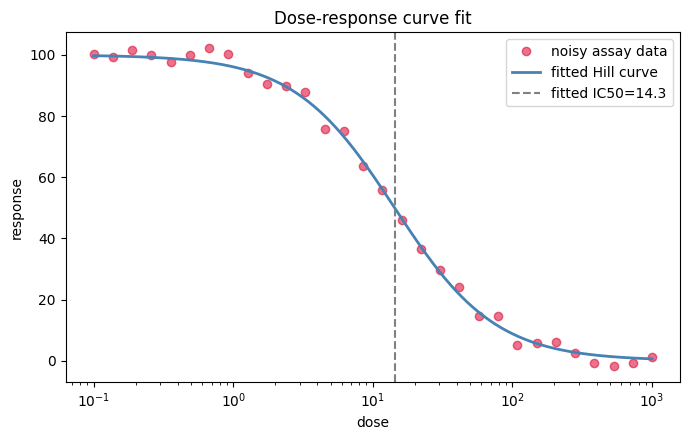

Bootstrap 95% CI on IC50: [13.72, 15.03]  (point estimate 14.33, true value 15.0)


In [5]:
dose_smooth = np.logspace(-1, 3, 300)
fitted_curve = dds.hill_equation(dose_smooth, fit['IC50'], fit['hill_coefficient'])

fig, ax = plt.subplots(figsize=(7,4.5))
ax.semilogx(doses, responses, 'o', color='crimson', alpha=0.6, label='noisy assay data')
ax.semilogx(dose_smooth, fitted_curve, color='steelblue', lw=2, label='fitted Hill curve')
ax.axvline(fit['IC50'], color='gray', ls='--', label=f"fitted IC50={fit['IC50']:.1f}")
ax.set_xlabel('dose'); ax.set_ylabel('response')
ax.set_title('Dose-response curve fit')
ax.legend()
plt.tight_layout()
plt.savefig('dose_response_fit.png', dpi=100, bbox_inches='tight')
plt.show()

boot = dds.bootstrap_ic50_ci(doses, responses, n_boot=1000, seed=1)
print(f"Bootstrap 95% CI on IC50: [{boot['ci_lo']:.2f}, {boot['ci_hi']:.2f}]  "
      f"(point estimate {boot['IC50_point_estimate']:.2f}, true value {true_IC50})")


## 6. Parameter Sweep: QSAR -- Does logP Predict Potency?

A simple QSAR model: regress a molecular descriptor (logP, lipophilicity)
against measured potency (pIC50). Swept across increasing noise levels to
show when the correlation becomes statistically undetectable.


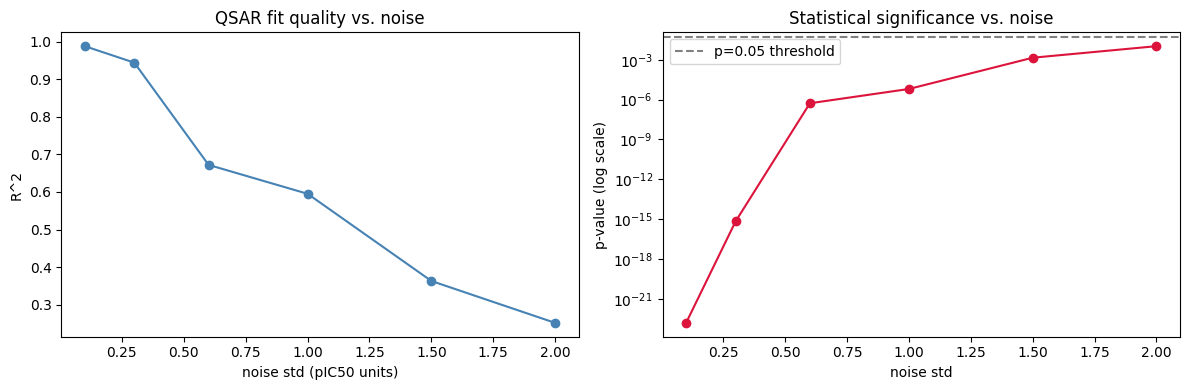

In [6]:
noise_levels = [0.1, 0.3, 0.6, 1.0, 1.5, 2.0]
r_squareds, p_values = [], []
for noise in noise_levels:
    logP = rng.uniform(-1, 5, 25)
    pIC50 = 4.0 + 0.6*logP + rng.normal(0, noise, 25)
    q = dds.qsar_linear_regression(logP, pIC50)
    r_squareds.append(q['r_squared'])
    p_values.append(q['p_value'])

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(noise_levels, r_squareds, 'o-', color='steelblue')
axes[0].set_xlabel('noise std (pIC50 units)'); axes[0].set_ylabel('R^2')
axes[0].set_title('QSAR fit quality vs. noise')
axes[1].semilogy(noise_levels, p_values, 'o-', color='crimson')
axes[1].axhline(0.05, color='gray', ls='--', label='p=0.05 threshold')
axes[1].set_xlabel('noise std'); axes[1].set_ylabel('p-value (log scale)')
axes[1].set_title('Statistical significance vs. noise'); axes[1].legend()
plt.tight_layout()
plt.savefig('qsar_noise_sweep.png', dpi=100, bbox_inches='tight')
plt.show()


## 7. Engineering Interpretation

- Lipinski screening is CHEAP (no synthesis needed) and happens before
  section 4's dose-response assay, which requires an actual synthesized,
  tested compound -- the stage ordering in this notebook matches the real
  cost/information tradeoff in a drug discovery pipeline.
- Section 5's bootstrap CI matters because `curve_fit`'s covariance-based
  standard error assumes locally-linear, Gaussian-residual behavior near
  the optimum -- often a poor assumption for a nonlinear 2-parameter fit
  on real noisy assay data; the bootstrap gives a distribution-free
  alternative without that assumption.
- Section 6 makes concrete WHY a QSAR model needs a minimum number of
  compounds and a minimum signal-to-noise ratio before its correlation
  claim is trustworthy -- a real, quantified version of "correlation
  doesn't have a p-value until you've done the statistics."


## 8. Research Discussion

- This notebook's QSAR model uses ONE descriptor (logP). Real QSAR
  typically uses many molecular descriptors simultaneously (multiple
  linear regression or a learned model) -- extending
  `qsar_linear_regression` to multivariate regression is a natural next
  step, with the same significance-testing logic applied per coefficient.
- Could `dgs.hypothesis.permutation_test` (already in this repo) provide
  an alternative, assumption-free significance test for
  `compare_compounds`, to cross-check the parametric Welch's t-test result
  the way this notebook already cross-checks `curve_fit`'s covariance
  errors against a bootstrap?


## 9. Possible Experiments

1. Extend `qsar_linear_regression` to multiple descriptors (multivariate
   regression) and compare its predictive R^2 against the single-descriptor
   version on the same synthetic dataset.
2. Cross-check `compare_compounds`'s Welch's t-test against
   `dgs.hypothesis.permutation_test` on the same synthetic compound data,
   confirming both methods agree on significance.
3. Replace the top/bottom-fixed 2-parameter Hill fit with a full
   4-parameter fit (top and bottom also free) on a dataset where the assay
   plateaus are NOT already known, and check whether IC50 recovery
   degrades.


## 10. Future Improvements

- If real (not synthetic) assay data becomes available, replace this
  notebook's synthetic dose-response/QSAR datasets with it and re-run
  sections 4-6 against real numbers.
- Cross-link this notebook from `dgs/biostatistics.py`'s module docstring
  (its Kaplan-Meier/log-rank survival analysis is the CLINICAL-TRIAL
  stage of the same overall pipeline this notebook's earlier, cheaper
  discovery-stage statistics feed into).
